# US Brewery Visits Heatmap

This notebook creates a heatmap visualization of brewery visits across the United States using the provided brewery data.

In [29]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [30]:
# Read the CSV file
df = pd.read_csv('main/breweries.csv', encoding='latin1')

# Filter out non-US locations (removing Canada entries)
df = df[df['State'] != 'Canada']

# Create a map of state abbreviations to full names
## there MUST be a package for this
state_names = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland', 
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}

# Convert state abbreviations to full names
df['State_Full'] = df['State'].map(state_names)

In [31]:
# Count breweries by state and convert to state abbreviations
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Count']

# Display the first few rows of the counts
print("Brewery visits by state:")
state_counts.head(3)

Brewery visits by state:


,State,Count
0,CO,196
1,NY,82
2,AZ,24


### geopandas static

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
"""Changing the colormap (e.g., 'viridis', 'YlOrRd', 'Blues')
Adjusting the font sizes of labels
Moving the inset maps to different positions
Changing the figure size
Adding additional annotations or context
"""

In [71]:
#gdf2 = gpd.read_file("main/shapefiles2/ne_10m_admin_1_states_provinces_lakes.shp")
data2 = (gdf2[gdf2['admin'] == 'United States of America']
         .merge(state_counts, how="left", left_on="postal", right_on="State")
)
data2.rename(columns={'postal':'STUSPS'}, inplace=True)
len(data2)

51

In [97]:
import numpy as np
data2['CountColor'] = data2['Count']**(1/8)

464.0

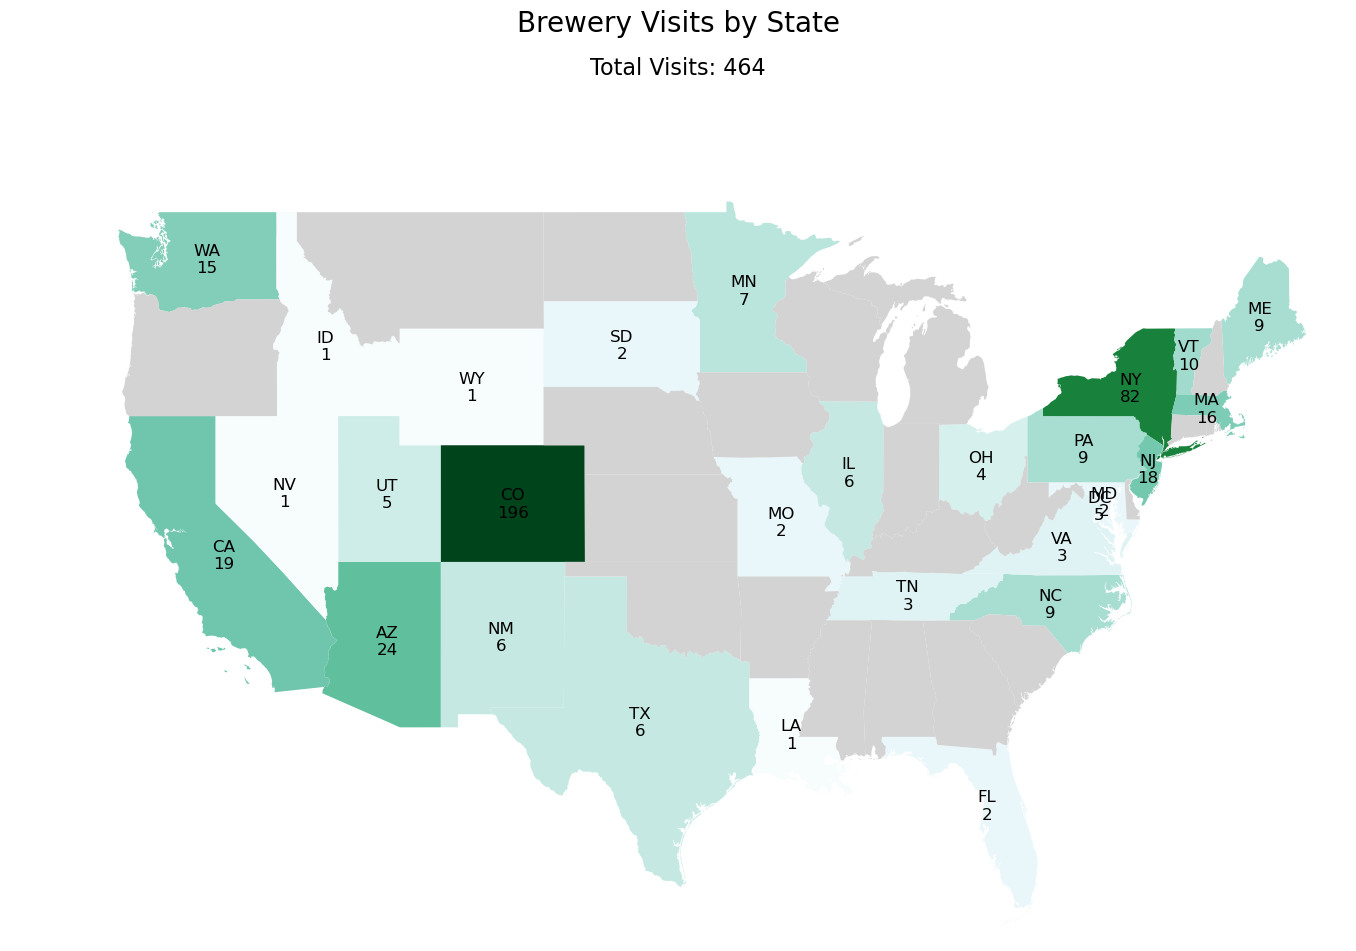

In [112]:
# Create the figure with white background
fig, ax = plt.subplots(1, 1, figsize=(15, 10), facecolor='white')
ax.set_facecolor('white')

# Create the map
data2.plot(
    column='CountColor',
    ax=ax,
    legend=False,
    missing_kwds={'color': 'lightgrey'},
    cmap='BuGn'
)

# Customize the map
ax.axis('off')  # Remove axes
ax.set_title('Brewery Visits by State', fontsize=20, pad=0)

total = str(int(data2['Count'].sum()))
plt.suptitle(f'Total Visits: {total}', y=.9, fontsize=16)

# Add state labels
for idx, row in data2.iterrows():
    # Skip AK and HI for now as they're outside the main map area
    if row['STUSPS'] not in ['AK', 'HI']:
        # Get the centroid of each state
        centroid = row.geometry.centroid
        # Add the state abbreviation and count
        if not pd.isna(row['Count']):
            ax.annotate(
                f"{row['STUSPS']}\n{int(row['Count'])}",
                xy=(centroid.x, centroid.y),
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=12
            )

# Set the map extent for continental US (lower 48 states)
ax.set_xlim(-130, -65)
ax.set_ylim(24, 55)

# Remove any default background colors
plt.gca().patch.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')

plt.tight_layout()
plt.show()

### Plotly dynamic

In [22]:
# Create the choropleth map
fig = go.Figure(data=go.Choropleth(
    locations=state_counts['State'],
    locationmode='USA-states',
    z=state_counts['Count'],
    colorscale='Reds',
    colorbar_title="Counts",
    text=[f"{state}: {count} breweries" for state, count in zip(state_counts['State'], state_counts['Count'])],  # Hover text
    #hoverinfo='text'
))

# Update the layout
fig.update_layout(
    title_text='Brewery Visits by State',
    geo_scope='usa',
    width=1000,
    height=600,
    title={
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)

# Show the map
fig.show()